In [1]:
!sudo apt update
!sudo apt install -y zstd
!curl -fsSL https://ollama.com/install.sh | sh
!pip install langchain-ollama
!pip install rouge-score bert-score ragas sacrebleu

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,389 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://cli.github.com/packages stable/main amd64 Packages [357 B]
Hit:8 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:12 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:13 http://security.ubuntu.com/ubuntu jammy

In [2]:
import threading
import subprocess
import time

def run_ollama_serve():
  subprocess.Popen(["ollama", "serve"])

thread = threading.Thread(target=run_ollama_serve)
thread.start()
time.sleep(5)

In [3]:
!ollama pull llama3.2

In [4]:
# !ollama pull llama3.2

In [5]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/Evaluation_dataset_400_with_ids.csv")
df.head()

,question,ground_truth,context,source_file,source_name,source_url,true_chunk_id
0,What is the current state of TB infection cont...,"At present, the knowledge and practice on TB i...","workers, children and other patients in these ...",Final TB Infection Control Guidelines 2011.md,Ministry of Health Uganda,https://library.health.go.ug/file-download/dow...,Final TB Infection Control Guidelines 2011.md_1
1,What is a landmark achievement in the fight ag...,The existence of this TB infection control gui...,tight work practices and being innovative. Hea...,Final TB Infection Control Guidelines 2011.md,Ministry of Health Uganda,https://library.health.go.ug/file-download/dow...,Final TB Infection Control Guidelines 2011.md_2
2,What is the name of the programme that provide...,Tuberculosis Control Assistance Programme (TBCAP),Regional Centre for Quality Health Care (RCQHC...,Final TB Infection Control Guidelines 2011.md,Ministry of Health Uganda,https://library.health.go.ug/file-download/dow...,Final TB Infection Control Guidelines 2011.md_3
3,What is the name of the Regional Centre for Qu...,Dr. Chilunga Puta,Dr Abel Nkolo National Professional Officer TB...,Final TB Infection Control Guidelines 2011.md,Ministry of Health Uganda,https://library.health.go.ug/file-download/dow...,Final TB Infection Control Guidelines 2011.md_4
4,What is the term for Multi Drug Resistant TB?,MDR-TB,Dr Juliana Nabatanzi NTLP-ZTLS South East Zone...,Final TB Infection Control Guidelines 2011.md,Ministry of Health Uganda,https://library.health.go.ug/file-download/dow...,Final TB Infection Control Guidelines 2011.md_5


In [6]:
import requests
import pandas as pd
import time
import json
from tqdm import tqdm
from math import log2
from rouge_score import rouge_scorer
from bert_score import score as bertscore
from datetime import datetime
import os

# ================= CONFIG =================

API_URL = "https://helpcentre-dsi-mdr.emergentai.ug/chat"
INPUT_CSV = "Evaluation_dataset_400_with_ids.csv"
OUTPUT_CSV = "Eval_results_full_set_50_reranker.csv"

TOP_K = 5
MAX_QUESTIONS = 50
SLEEP_SEC = 2
TIMEOUT = 60
MAX_RETRIES = 3

# ================= METRIC FUNCTIONS =================

def precision_at_k(relevant, retrieved, k):
    return len(set(relevant) & set(retrieved[:k])) / k if k > 0 else 0

def recall_at_k(relevant, retrieved, k):
    return len(set(relevant) & set(retrieved[:k])) / len(relevant) if relevant else 0

def hit_at_k(relevant, retrieved, k):
    return 1 if len(set(relevant) & set(retrieved[:k])) > 0 else 0

def mrr_at_k(relevant, retrieved, k):
    for i, doc in enumerate(retrieved[:k]):
        if doc in relevant:
            return 1 / (i + 1)
    return 0

def ndcg_at_k(relevant, retrieved, k):
    dcg = sum(1/log2(i+2) for i, d in enumerate(retrieved[:k]) if d in relevant)
    idcg = sum(1/log2(i+2) for i in range(min(len(relevant), k)))
    return dcg/idcg if idcg > 0 else 0

def ap_at_k(relevant, retrieved, k):
    hits = 0
    score = 0
    for i, d in enumerate(retrieved[:k]):
        if d in relevant:
            hits += 1
            score += hits/(i+1)
    return score/len(relevant) if relevant else 0

# ================= LOAD DATA =================

df = pd.read_csv(INPUT_CSV)

# limit evaluation size
df = df.head(MAX_QUESTIONS)

# Resume support
if os.path.exists(OUTPUT_CSV):
    done_df = pd.read_csv(OUTPUT_CSV)
    done_questions = set(done_df["question"])
else:
    done_questions = set()

# ROUGE scorer
scorer = rouge_scorer.RougeScorer(["rouge1","rouge2","rougeL"], use_stemmer=True)

# ================= MAIN LOOP =================

for _, row in tqdm(df.iterrows(), total=len(df)):

    question = row["question"]
    gt_answer = str(row["ground_truth"])
    true_chunk = row["true_chunk_id"]

    if question in done_questions:
        continue

    payload = {"query": question}

    retries = 0
    success = False
    latency = None
    answer = ""
    retrieved_ids = []

    while retries < MAX_RETRIES and not success:
        try:
            start = time.time()

            r = requests.post(
                API_URL,
                json=payload,
                timeout=TIMEOUT
            )

            latency = time.time() - start

            if r.status_code != 200:
                raise RuntimeError(f"HTTP {r.status_code}")

            data = r.json()
            success = True

        except Exception as e:
            retries += 1
            print(f"Retry {retries}/{MAX_RETRIES} for question:")
            print(question)
            print(e)
            time.sleep(2)

    # ================= HANDLE FAILURE =================

    if not success:

        result = {
            "question": question,
            "true_chunk_id": true_chunk,
            "ground_truth": gt_answer,
            "answer": "",
            "retrieved_chunk_ids": "[]",
            "precision@5": 0,
            "recall@5": 0,
            "hit@5": 0,
            "mrr@5": 0,
            "ndcg@5": 0,
            "map@5": 0,
            "rouge1": 0,
            "rouge2": 0,
            "rougeL": 0,
            "bertscore_f1": 0,
            "latency_sec": None,
            "status": "failed",
            "timestamp": datetime.utcnow().isoformat()
        }

        pd.DataFrame([result]).to_csv(
            OUTPUT_CSV,
            mode="a",
            index=False,
            header=not os.path.exists(OUTPUT_CSV)
        )

        continue

    # ================= PARSE RESPONSE =================

    answer = data.get("answer", "")
    sources = data.get("sources", [])

    # Extract retrieved chunk IDs safely
    for s in sources:
        if isinstance(s, dict) and "doc_id" in s:
            retrieved_ids.append(s["doc_id"])

    relevant = [true_chunk]

    # ================= RETRIEVER METRICS =================

    p5 = precision_at_k(relevant, retrieved_ids, TOP_K)
    r5 = recall_at_k(relevant, retrieved_ids, TOP_K)
    hit5 = hit_at_k(relevant, retrieved_ids, TOP_K)
    mrr5 = mrr_at_k(relevant, retrieved_ids, TOP_K)
    ndcg5 = ndcg_at_k(relevant, retrieved_ids, TOP_K)
    map5 = ap_at_k(relevant, retrieved_ids, TOP_K)

    # ================= GENERATOR METRICS =================

    rouge_scores = scorer.score(gt_answer, answer)

    rouge1 = rouge_scores["rouge1"].fmeasure
    rouge2 = rouge_scores["rouge2"].fmeasure
    rougeL = rouge_scores["rougeL"].fmeasure

    try:
        P, R, F1 = bertscore(
            [answer],
            [gt_answer],
            lang="en",
            model_type="microsoft/deberta-xlarge-mnli"
        )

        bert_f1 = F1.item()

    except:
        bert_f1 = 0

    # ================= SAVE RESULT =================

    result = {
        "question": question,
        "true_chunk_id": true_chunk,
        "ground_truth": gt_answer,
        "answer": answer,
        "retrieved_chunk_ids": json.dumps(retrieved_ids),
        "precision@5": p5,
        "recall@5": r5,
        "hit@5": hit5,
        "mrr@5": mrr5,
        "ndcg@5": ndcg5,
        "map@5": map5,
        "rouge1": rouge1,
        "rouge2": rouge2,
        "rougeL": rougeL,
        "bertscore_f1": bert_f1,
        "latency_sec": latency,
        "status": "ok",
        "timestamp": datetime.utcnow().isoformat()
    }

    pd.DataFrame([result]).to_csv(
        OUTPUT_CSV,
        mode="a",
        index=False,
        header=not os.path.exists(OUTPUT_CSV)
    )

    time.sleep(SLEEP_SEC)

print("Evaluation complete.")

  0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/792 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.bias   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
 98%|█████████▊| 49/50 [13:35<00:14, 14.19s/it]

Loading weights:   0%|          | 0/772 [00:00<?, ?it/s]

DebertaModel LOAD REPORT from: microsoft/deberta-xlarge-mnli
Key                 | Status     |  | 
--------------------+------------+--+-
pooler.dense.bias   | UNEXPECTED |  | 
pooler.dense.weight | UNEXPECTED |  | 
classifier.bias     | UNEXPECTED |  | 
classifier.weight   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 50/50 [13:50<00:00, 16.62s/it]

Evaluation complete.


In [8]:
import pandas as pd

# Load evaluation results
df = pd.read_csv("Eval_results_full_set_50_reranker.csv")

print("\n===== RAG SYSTEM EVALUATION RESULTS =====\n")

print("Retriever Metrics")
print("------------------")
print("Precision@5 :", df["precision@5"].mean())
print("Recall@5    :", df["recall@5"].mean())
print("Hit@5       :", df["hit@5"].mean())
print("MRR@5       :", df["mrr@5"].mean())
print("NDCG@5      :", df["ndcg@5"].mean())
print("MAP@5       :", df["map@5"].mean())

print("\nGenerator Metrics")
print("------------------")
print("ROUGE-L     :", df["rougeL"].mean())
print("BERTScore   :", df["bertscore_f1"].mean())

print("\nSystem Metrics")
print("------------------")
print("Average Latency (sec):", df["latency_sec"].mean())

print("\nTotal Questions Evaluated:", len(df))


===== RAG SYSTEM EVALUATION RESULTS =====

Retriever Metrics
------------------
Precision@5 : 0.14400000000000002
Recall@5    : 0.72
Hit@5       : 0.72
MRR@5       : 0.604
NDCG@5      : 0.6334486265732657
MAP@5       : 0.604

Generator Metrics
------------------
ROUGE-L     : 0.15387803920591953
BERTScore   : 0.0

System Metrics
------------------
Average Latency (sec): 7.76824460029602

Total Questions Evaluated: 50


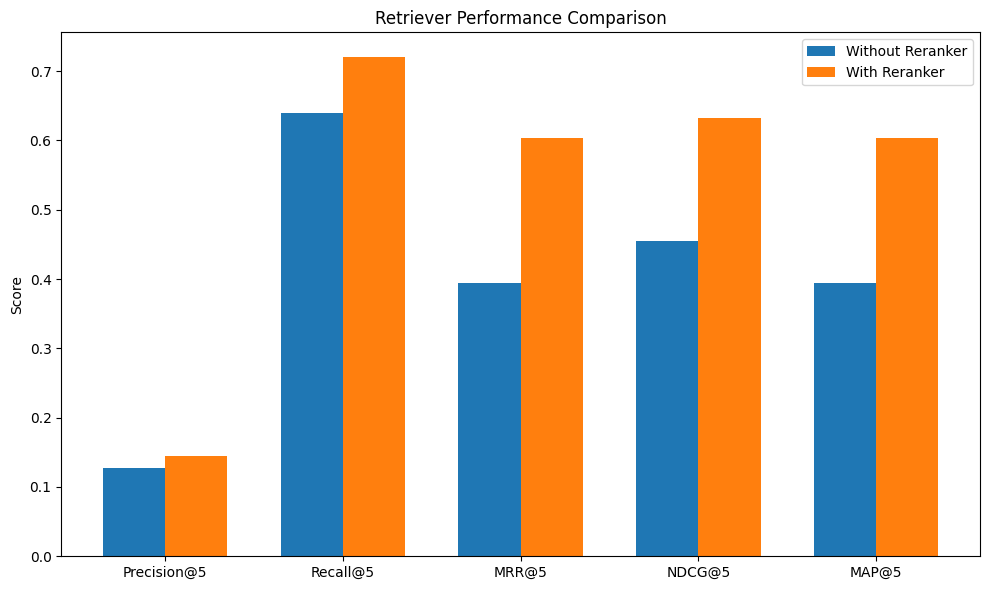

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Precision@5",
    "Recall@5",
    "MRR@5",
    "NDCG@5",
    "MAP@5"
]

without_reranker = [0.128, 0.64, 0.394, 0.455, 0.394]
with_reranker = [0.144, 0.72, 0.604, 0.633, 0.604]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10,6))

plt.bar(x - width/2, without_reranker, width, label="Without Reranker")
plt.bar(x + width/2, with_reranker, width, label="With Reranker")

plt.ylabel("Score")
plt.title("Retriever Performance Comparison")
plt.xticks(x, metrics)
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

df = pd.read_csv("Eval_results_full_set_50_reranker.csv")


In [10]:
df.head()

,question,true_chunk_id,ground_truth,answer,retrieved_chunk_ids,precision@5,recall@5,hit@5,mrr@5,ndcg@5,map@5,rouge1,rouge2,rougeL,bertscore_f1,latency_sec,status,timestamp
0,What is the current state of TB infection cont...,Final TB Infection Control Guidelines 2011.md_1,"At present, the knowledge and practice on TB i...","According to the provided information, the cur...","[""Final TB Infection Control Guidelines 2011.m...",0.2,1.0,1,1.0,1.00000,1.0,0.178571,0.117117,0.151786,0,7.572039,ok,2026-03-09T10:23:05.362970
1,What is a landmark achievement in the fight ag...,Final TB Infection Control Guidelines 2011.md_2,The existence of this TB infection control gui...,The provided information doesn’t detail a spec...,"[""Final TB Infection Control Guidelines 2011.m...",0.0,0.0,0,0.0,0.00000,0.0,0.131579,0.054054,0.105263,0,9.324506,ok,2026-03-09T10:23:27.009032
2,What is the name of the programme that provide...,Final TB Infection Control Guidelines 2011.md_3,Tuberculosis Control Assistance Programme (TBCAP),The provided information doesn’t explicitly na...,"[""TREATMENT OF TUBERCULOSIS guidelines.md_1400...",0.0,0.0,0,0.0,0.00000,0.0,0.092308,0.031746,0.092308,0,7.940712,ok,2026-03-09T10:23:42.422111
3,What is the name of the Regional Centre for Qu...,Final TB Infection Control Guidelines 2011.md_4,Dr. Chilunga Puta,The Regional Centre for Quality of Health Care...,"[""Final TB Infection Control Guidelines 2011.m...",0.2,1.0,1,0.5,0.63093,0.5,0.000000,0.000000,0.000000,0,5.628437,ok,2026-03-09T10:23:55.564554
4,What is the term for Multi Drug Resistant TB?,Final TB Infection Control Guidelines 2011.md_5,MDR-TB,Multidrug-resistant TB (MDR TB) is defined as ...,"[""Question_Answers_About_TB_English.md_848"", ""...",0.0,0.0,0,0.0,0.00000,0.0,0.039216,0.020000,0.039216,0,12.782939,ok,2026-03-09T10:24:15.823473


In [11]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [12]:
import pandas as pd
import json
from tqdm import tqdm
from ragas import EvaluationDataset

df = pd.read_csv("Eval_results_full_set_50_reranker.csv")

dataset_list = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    # retrieved contexts
    contexts = []

    try:
        ids = json.loads(row["retrieved_chunk_ids"])
        contexts = ids  # replace with real text if available
    except:
        contexts = []

    dataset_list.append({
        "user_input": row["question"],
        "reference": row["ground_truth"],
        "response": row["answer"],
        "retrieved_contexts": contexts
    })

dataset = EvaluationDataset.from_list(dataset_list)

print(dataset.features())

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
100%|██████████| 50/50 [00:00<00:00, 9562.06it/s]

['user_input', 'retrieved_contexts', 'response', 'reference']


In [13]:
from langchain_community.chat_models import ChatOllama
from ragas.llms import LangchainLLMWrapper

llm = ChatOllama(
    model="llama3.2",
    temperature=0.1
)

llm_wrapper = LangchainLLMWrapper(llm)

/tmp/ipykernel_504/2598989954.py:4: LangChainDeprecationWarning: The class `ChatOllama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the `langchain-ollama package and should be used instead. To use it run `pip install -U `langchain-ollama` and import as `from `langchain_ollama import ChatOllama``.
  llm = ChatOllama(
/tmp/ipykernel_504/2598989954.py:9: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  llm_wrapper = LangchainLLMWrapper(llm)


In [14]:
from ragas.metrics import (
    BleuScore,
    ContextRecall,
    Faithfulness,
    FactualCorrectness
)

/tmp/ipykernel_504/447493662.py:1: DeprecationWarning: Importing BleuScore from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import BleuScore
  from ragas.metrics import (
/tmp/ipykernel_504/447493662.py:1: DeprecationWarning: Importing ContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ContextRecall
  from ragas.metrics import (
/tmp/ipykernel_504/447493662.py:1: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import (
/tmp/ipykernel_504/447493662.py:1: DeprecationWarning: Importing FactualCorrectness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'raga

In [15]:
from ragas import evaluate
import time

metrics = [
    BleuScore(),
    ContextRecall(),
    Faithfulness(),
    FactualCorrectness(mode="f1")
]

print("Starting RAGAS evaluation...")

start = time.time()

results = evaluate(
    dataset=dataset,
    metrics=metrics,
    llm=llm_wrapper,
    show_progress=True
)

end = time.time()

print("\nEvaluation finished in", round(end-start,2), "seconds")
print(results)

Starting RAGAS evaluation...


Evaluating:   0%|          | 0/200 [00:00<?, ?it/s]

ERROR:ragas.executor:Exception raised in Job[2]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[6]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[3]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[10]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[14]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[18]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[7]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[11]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[15]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[19]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[22]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[31]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[34]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[35]: TimeoutError()
ERROR:ragas.executor:Exception raised in Job[38]: TimeoutError()
ERROR:ragas.executor:Exceptio


Evaluation finished in 1439.83 seconds
{'bleu_score': 0.1125, 'context_recall': 0.8657, 'faithfulness': 0.7825, 'factual_correctness(mode=f1)': 0.5057}


In [16]:
print(results)

{'bleu_score': 0.1125, 'context_recall': 0.8657, 'faithfulness': 0.7825, 'factual_correctness(mode=f1)': 0.5057}


In [17]:
dataset

EvaluationDataset(features=['user_input', 'retrieved_contexts', 'response', 'reference'], len=50)

In [18]:
metrics

[BleuScore(_required_columns={<MetricType.SINGLE_TURN: 'single_turn'>: {'response', 'reference'}}, name='bleu_score', kwargs={}),
 ContextRecall(_required_columns={<MetricType.SINGLE_TURN: 'single_turn'>: {'retrieved_contexts', 'reference', 'user_input'}}, name='context_recall', llm=None, output_type=<MetricOutputType.CONTINUOUS: 'continuous'>, context_recall_prompt=ContextRecallClassificationPrompt(instruction=Given a context, and an answer, analyze each sentence in the answer and classify if the sentence can be attributed to the given context or not. Use only 'Yes' (1) or 'No' (0) as a binary classification. Output json with reason., examples=[(QCA(question='What can you tell me about albert Albert Einstein?', context="Albert Einstein (14 March 1879 - 18 April 1955) was a German-born theoretical physicist, widely held to be one of the greatest and most influential scientists of all time. Best known for developing the theory of relativity, he also made important contributions to quant

In [ ]:
# pd.DataFrame([scores]).to_csv("ragas_scores.csv", index=False)

In [19]:
results

{'bleu_score': 0.1125, 'context_recall': 0.8657, 'faithfulness': 0.7825, 'factual_correctness(mode=f1)': 0.5057}

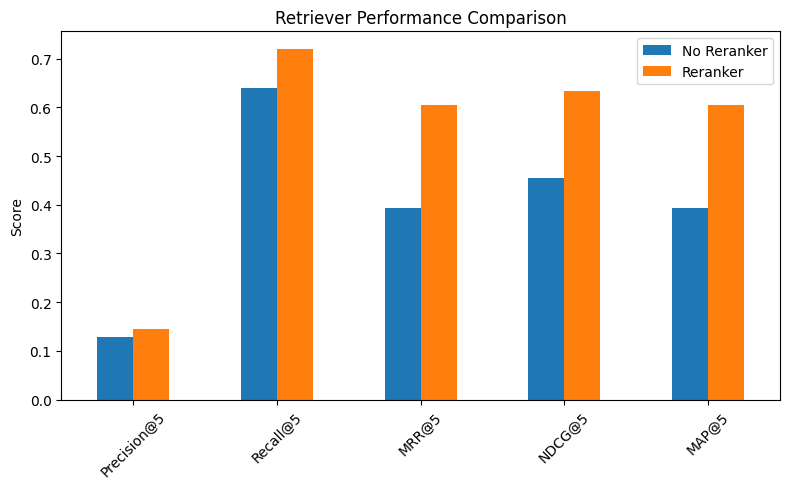

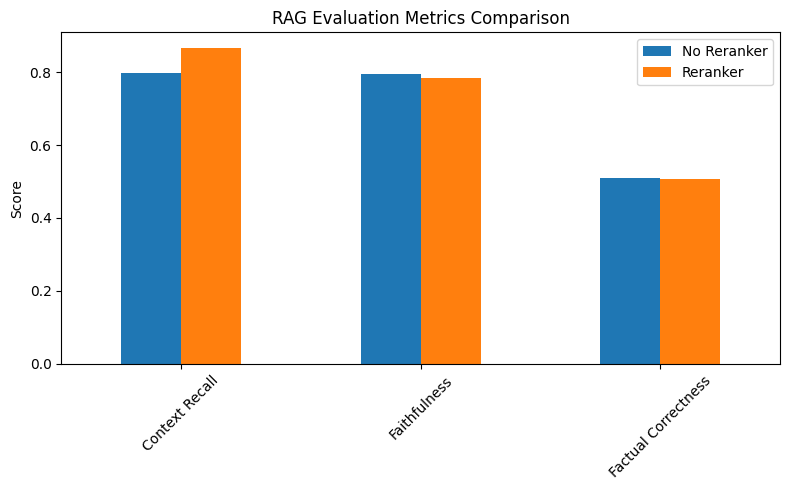

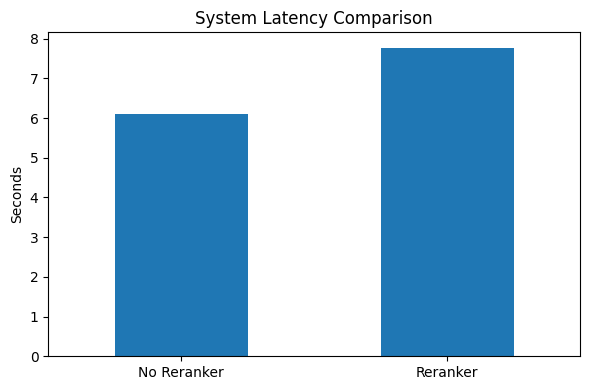

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from your experiments
retriever = pd.DataFrame({
    "No Reranker": [0.128, 0.64, 0.394, 0.455, 0.394],
    "Reranker":    [0.144, 0.72, 0.604, 0.633, 0.604]
}, index=["Precision@5","Recall@5","MRR@5","NDCG@5","MAP@5"])

rag_metrics = pd.DataFrame({
    "No Reranker": [0.7976,0.7937,0.5109],
    "Reranker":    [0.8657,0.7825,0.5057]
}, index=["Context Recall","Faithfulness","Factual Correctness"])

latency = pd.DataFrame({
    "Latency (sec)": [6.11,7.77]
}, index=["No Reranker","Reranker"])

# Plot retriever metrics
retriever.plot(kind="bar", figsize=(8,5))
plt.title("Retriever Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot RAG evaluation metrics
rag_metrics.plot(kind="bar", figsize=(8,5))
plt.title("RAG Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot latency comparison
latency.plot(kind="bar", figsize=(6,4), legend=False)
plt.title("System Latency Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

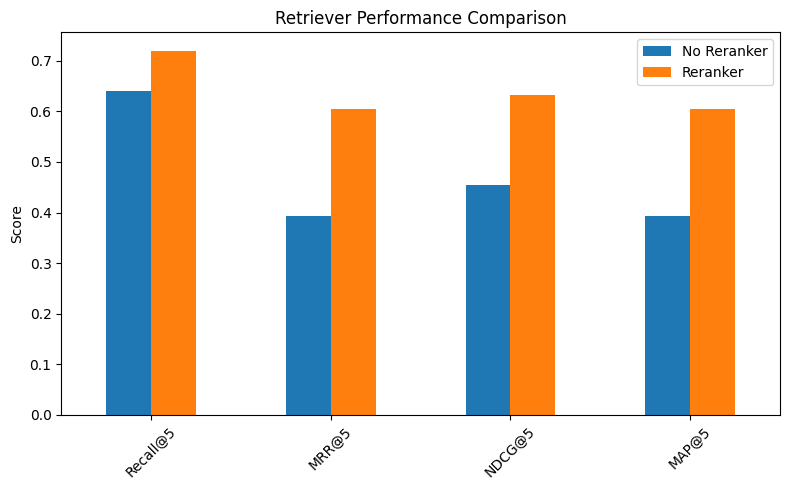

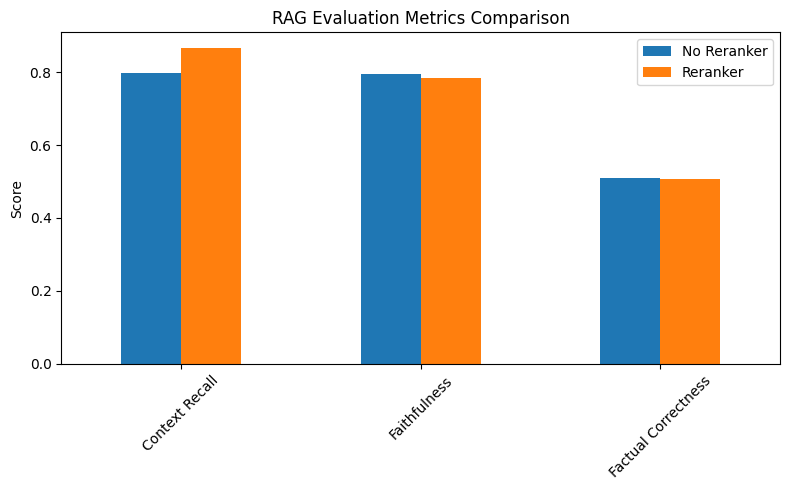

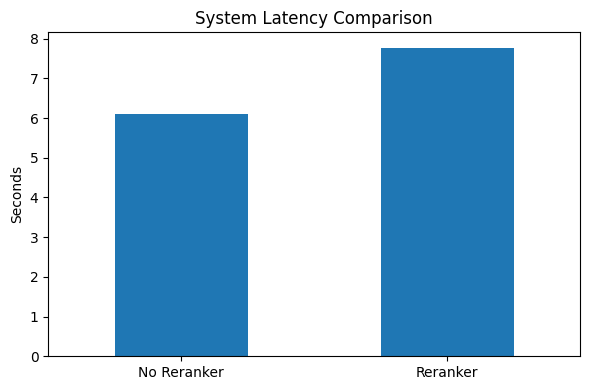

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from your experiments
retriever = pd.DataFrame({
    "No Reranker": [0.64, 0.394, 0.455, 0.394],
    "Reranker":    [0.72, 0.604, 0.633, 0.604]
}, index=["Recall@5","MRR@5","NDCG@5","MAP@5"])

rag_metrics = pd.DataFrame({
    "No Reranker": [0.7976,0.7937,0.5109],
    "Reranker":    [0.8657,0.7825,0.5057]
}, index=["Context Recall","Faithfulness","Factual Correctness"])

latency = pd.DataFrame({
    "Latency (sec)": [6.11,7.77]
}, index=["No Reranker","Reranker"])

# Plot retriever metrics
retriever.plot(kind="bar", figsize=(8,5))
plt.title("Retriever Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot RAG evaluation metrics
rag_metrics.plot(kind="bar", figsize=(8,5))
plt.title("RAG Evaluation Metrics Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot latency comparison
latency.plot(kind="bar", figsize=(6,4), legend=False)
plt.title("System Latency Comparison")
plt.ylabel("Seconds")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
results_dict = results

# Convert to dataframe
df = pd.DataFrame([results_dict])

# Save to CSV
df.to_csv("ragas_summary_results.csv", index=False)

print("Results saved to ragas_summary_results.csv")

print(results_dict)

Results saved to ragas_summary_results.csv
{'bleu_score': 0.1125, 'context_recall': 0.8657, 'faithfulness': 0.7825, 'factual_correctness(mode=f1)': 0.5057}


In [22]:
df = pd.read_csv("ragas_summary_results.csv")
df.head()

,scores,dataset,binary_columns,cost_cb,traces,ragas_traces,run_id
0,"[{'bleu_score': 0.40283046047758814, 'context_...",{'samples': [SingleTurnSample(user_input='What...,[],NaN,[{'scores': {'bleu_score': 0.40283046047758814...,{'019cd22e-ce87-7ec0-96ab-7bd141e716bc': Chain...,NaN


In [25]:
import pandas as pd
import ast

df = pd.read_csv("ragas_summary_results.csv")

# The 'ragas_summary_results.csv' file, as generated by the previous step,
# contains the aggregate scores (e.g., bleu_score, context_recall) directly as columns.
# Therefore, there is no 'scores' column to parse or explode.
# The 'df' DataFrame already holds the aggregated results.

# Assign the loaded DataFrame directly to scores_df as it contains the aggregated results.
scores_df = df

scores_df

,scores,dataset,binary_columns,cost_cb,traces,ragas_traces,run_id
0,"[{'bleu_score': 0.40283046047758814, 'context_...",{'samples': [SingleTurnSample(user_input='What...,[],NaN,[{'scores': {'bleu_score': 0.40283046047758814...,{'019cd22e-ce87-7ec0-96ab-7bd141e716bc': Chain...,NaN


In [30]:
import pandas as pd

df = pd.read_csv("ragas_summary_results.csv")

# Extract metric values from the text column
metrics = ["bleu_score", "context_recall", "faithfulness", "factual_correctness"]

for m in metrics:
    df[m] = df["scores"].str.extract(fr"{m}': ([0-9\.]+)").astype(float)

clean_df = df[metrics]

print(clean_df.head())

   bleu_score  context_recall  faithfulness  factual_correctness
0     0.40283             1.0           1.0                  NaN


In [32]:
results_dict = results.scores

import pandas as pd
pd.DataFrame([results_dict]).to_csv("ragas_clean_results.csv", index=False)

In [34]:

df = pd.read_csv("ragas_clean_results.csv")
df.head()

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
0,"{'bleu_score': 0.40283046047758814, 'context_r...","{'bleu_score': 0.1235622127262679, 'context_re...","{'bleu_score': 0.0, 'context_recall': 1.0, 'fa...","{'bleu_score': 0.0, 'context_recall': 1.0, 'fa...","{'bleu_score': 0.0, 'context_recall': 1.0, 'fa...","{'bleu_score': 0.020244462660665506, 'context_...","{'bleu_score': 0.31541318910947735, 'context_r...","{'bleu_score': 0.022731543567022873, 'context_...","{'bleu_score': 0.0025657186078124183, 'context...","{'bleu_score': 0.4289031790194939, 'context_re...",...,"{'bleu_score': 0.33336191742083476, 'context_r...","{'bleu_score': 0.15747597298550434, 'context_r...","{'bleu_score': 0.0757687117425842, 'context_re...","{'bleu_score': 0.2504037387704623, 'context_re...","{'bleu_score': 0.2046592065585361, 'context_re...","{'bleu_score': 0.047612989461161256, 'context_...","{'bleu_score': 0.06468490584192434, 'context_r...","{'bleu_score': 0.0322783642152686, 'context_re...","{'bleu_score': 0.010009398039350848, 'context_...","{'bleu_score': 0.0, 'context_recall': 1.0, 'fa..."
